# **Setup, Path Configuration and Installing necessaary packages**

In [2]:
# Detect environment and set paths accordingly
import os

try:
    # Check if running in Google Colab
    from google.colab import drive
    drive.mount('/content/drive')
    DRIVE_ROOT = "/content/drive/MyDrive/dbpedia_project"
    print("Running in Google Colab. Using Google Drive path.")
except ImportError:
    # Running locally - use local dbpedia_project directory
    DRIVE_ROOT = os.path.join(os.getcwd(), "dbpedia_project")
    print(f"Running locally. Using local path: {DRIVE_ROOT}")

Mounted at /content/drive
Running in Google Colab. Using Google Drive path.


In [3]:
os.makedirs(DRIVE_ROOT, exist_ok=True)
os.makedirs(os.path.join(DRIVE_ROOT, "model"), exist_ok=True)
os.makedirs(os.path.join(DRIVE_ROOT, "checkpoints"), exist_ok=True)

In [4]:
TRAIN_PATH = os.path.join(DRIVE_ROOT, "train.csv")
TEST_PATH  = os.path.join(DRIVE_ROOT, "test.csv")
MODEL_SAVE_DIR = os.path.join(DRIVE_ROOT, "model")
CHECKPOINTS_DIR = os.path.join(DRIVE_ROOT, "checkpoints")

print("TRAIN_PATH:", TRAIN_PATH)
print("TEST_PATH:", TEST_PATH)
print("MODEL_SAVE_DIR:", MODEL_SAVE_DIR)

TRAIN_PATH: /content/drive/MyDrive/dbpedia_project/train.csv
TEST_PATH: /content/drive/MyDrive/dbpedia_project/test.csv
MODEL_SAVE_DIR: /content/drive/MyDrive/dbpedia_project/model


In [5]:
!pip install -q transformers datasets evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.8 MB/s eta 0:00:00


In [6]:
!pip install -q scikit-learn pandas matplotlib seaborn

In [7]:
!pip install -q lime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 8.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [ ]:
!pip install -U transformers accelerate datasets evaluate

In [8]:
!pip install torch

In [9]:
import os, random, numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)

set_seed(42)


In [ ]:
from lime.lime_text import LimeTextExplainer
import numpy as np
import torch

In [ ]:
from datasets import Dataset
from transformers import AutoTokenizer

#**Loading DBpedia Dataset**

Here the text and test datasets are loaded and the columns are labelled as "label", "title" and "text".

Also the "text" column is given the title name as the reference in it, in order to avoid any missing values(which there are not any) in the dataset.

In [10]:
train_df = pd.read_csv(TRAIN_PATH, header=None, names=["label","title","text"])
test_df  = pd.read_csv(TEST_PATH,  header=None, names=["label","title","text"])

train_df["text"] = train_df["title"].fillna("").astype(str) + ". " + train_df["text"].fillna("").astype(str)
test_df["text"]  = test_df["title"].fillna("").astype(str) + ". " + test_df["text"].fillna("").astype(str)

train_df = train_df[train_df["text"].str.strip().astype(bool)]
test_df  = test_df[test_df["text"].str.strip().astype(bool)]

if train_df["label"].max() > 13:
    train_df["label"] -= 1
    test_df["label"]  -= 1

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

Train shape: (560000, 3)
Test shape: (70000, 3)


In [11]:
train_df.head()

,label,title,text
0,0,E. D. Abbott Ltd,E. D. Abbott Ltd. Abbott of Farnham E D Abbot...
1,0,Schwan-Stabilo,Schwan-Stabilo. Schwan-STABILO is a German ma...
2,0,Q-workshop,Q-workshop. Q-workshop is a Polish company lo...
3,0,Marvell Software Solutions Israel,Marvell Software Solutions Israel. Marvell So...
4,0,Bergan Mercy Medical Center,Bergan Mercy Medical Center. Bergan Mercy Med...


In [ ]:
num_labels = 14
MAX_LENGTH = 256

In [ ]:
DBPEDIA_LABELS = [
    "Company",
    "EducationalInstitution",
    "Artist",
    "Athlete",
    "OfficeHolder",
    "MeanOfTransportation",
    "Building",
    "NaturalPlace",
    "Village",
    "Animal",
    "Plant",
    "Album",
    "Film",
    "WrittenWork"
]


#**Train/Validation Split**

10% of the training dataset is further split into validation dataset

In [12]:
from sklearn.model_selection import train_test_split

train_texts, val_texts, train_labels, val_labels = train_test_split(
    train_df["text"], train_df["label"], test_size=0.1, stratify=train_df["label"], random_state=42
)

print("Train:", len(train_texts), "Val:", len(val_texts))


Train: 504000 Val: 56000


#**EDA (Class Distribution + Stats + Examples)**

##**Class Distribution**

To see the number of entries for each label (in training + validation data). In total there are 14 labels with 40000 entries for each

/tmp/ipython-input-3780249534.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x=train_df["label"], palette="Blues")


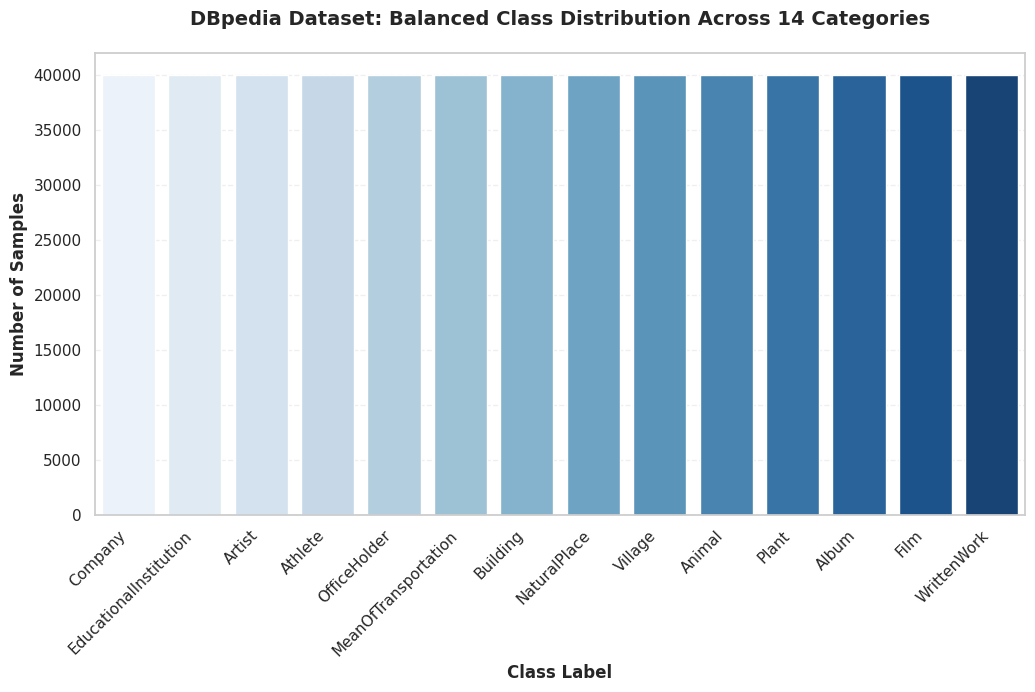

In [13]:

class_names = []
with open(os.path.join(DRIVE_ROOT, "classes.txt"), "r") as f:
    class_names = [line.strip() for line in f if line.strip()]

plt.figure(figsize=(12,6))
ax = sns.countplot(x=train_df["label"], palette="Blues")
plt.title("DBpedia Dataset: Balanced Class Distribution Across 14 Categories", fontsize=14, fontweight='bold', pad=20)
plt.xlabel("Class Label", fontsize=12, fontweight='bold')
plt.ylabel("Number of Samples", fontsize=12, fontweight='bold')
plt.xticks(range(14), [f"{class_names[i]}" if i < len(class_names) else str(i) for i in range(14)], rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3, linestyle='--')

plt.show()


##**Text Length Stats**

To see the average number of words in each entry

count    560000.000000
mean         48.873950
std          22.693658
min           2.000000
25%          29.000000
50%          49.000000
75%          68.000000
max        1485.000000
Name: len_words, dtype: float64


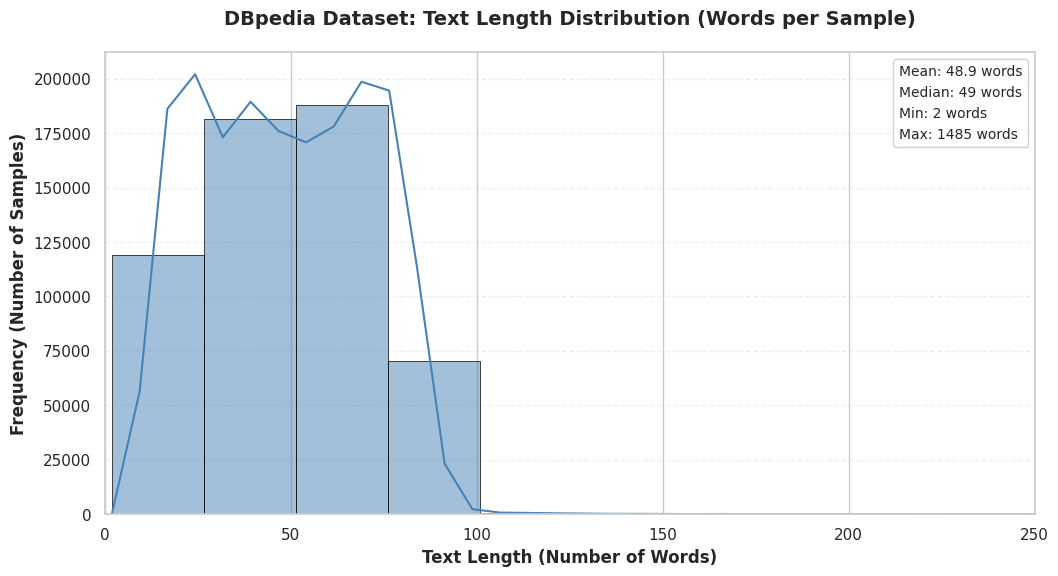

In [14]:
train_df["len_words"] = train_df["text"].str.split().apply(len)
print(train_df["len_words"].describe())

plt.figure(figsize=(12,6))
ax = sns.histplot(train_df["len_words"], bins=60, kde=True, color='steelblue', edgecolor='black', linewidth=0.5)
plt.xlim(0, 250)
plt.title("DBpedia Dataset: Text Length Distribution (Words per Sample)",
          fontsize=14, fontweight='bold', pad=20)
plt.xlabel("Text Length (Number of Words)", fontsize=12, fontweight='bold')
plt.ylabel("Frequency (Number of Samples)", fontsize=12, fontweight='bold')

# Custom Legend
from matplotlib.patches import Patch
legend_elements = [
    f'Mean: {train_df["len_words"].mean():.1f} words',
    f'Median: {train_df["len_words"].median():.0f} words',
    f'Min: {train_df["len_words"].min():.0f} words',
    f'Max: {train_df["len_words"].max():.0f} words'
]
plt.legend(handles=[Patch(facecolor='none', edgecolor='none', label=label) for label in legend_elements],
           loc='upper right', fontsize=10, framealpha=0.9, handlelength=0, handletextpad=0)

plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.show()


##**Example Samples**

Some entries from each label

In [15]:
for i in range(14):
    print(f"{class_names[i]} Example:", train_df[train_df["label"]==i]["text"].iloc[0][:200], "\n---")


Company Example: E. D. Abbott Ltd.  Abbott of Farnham E D Abbott Limited was a British coachbuilding business based in Farnham Surrey trading under that name from 1929. A major part of their output was under sub-contr 
---
EducationalInstitution Example: Dubai Gem Private School & Nursery.  Dubai Gem Private School (DGPS) is a British school located in the Oud Metha area of Dubai United Arab Emirates. Dubai Gem Nursery is located in Jumeirah. Together 
---
Artist Example: Erin Morgenstern.  Erin Morgenstern (born July 8 1978) is an American writer and visual artist best known for writing The Night Circus. 
---
Athlete Example: Martin McKinnon.  Martin Marty McKinnon (born 5 July 1975 in Adelaide) is a former Australian rules footballer who played with Adelaide Geelong and the Brisbane Lions in the Australian Football League 
---
OfficeHolder Example: Augustus Porter.  Augustus S. Porter (January 18 1769 – June 10 1849) was an American businessman judge farmer and politician who served 

###**Most Common Words per Class**

In [ ]:
from collections import Counter
import nltk
nltk.download("stopwords")
stopwords = set(nltk.corpus.stopwords.words("english"))

def get_top_words(df, label, n=20):
    texts = " ".join(df[df.label==label].text).lower().split()
    words = [w for w in texts if w not in stopwords]
    return Counter(words).most_common(n)

for lbl in sorted(train_df.label.unique()):
    print(f"\nTop words for class {lbl}")
    print(get_top_words(train_df, lbl))


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.



Top words for class 0
[('company', 28025), ('founded', 10571), ('based', 10159), ('services', 5138), ('group', 5072), ('united', 5045), ('new', 5021), ('label', 4617), ('&', 4404), ('also', 4389), ('american', 4213), ('largest', 4197), ('owned', 4157), ('one', 4119), ('international', 4117), ('inc.', 4100), ('headquartered', 4095), ('known', 4059), ('bank', 3671), ('first', 3535)]

Top words for class 1
[('school', 91305), ('high', 41195), ('university', 24586), ('college', 22079), ('located', 20900), ('school.', 15915), ('public', 12985), ('students', 10119), ('secondary', 8338), ('district', 7655), ('education', 7477), ('schools', 7466), ('founded', 6797), ('county', 6478), ('new', 6315), ('one', 6269), ('private', 5668), ('city', 5580), ('catholic', 5579), ('established', 5481)]

Top words for class 2
[('(born', 16620), ('known', 12392), ('american', 11871), ('born', 8040), ('–', 7892), ('also', 6606), ('music', 6568), ('best', 5789), ('singer', 5724), ('new', 4914), ('band', 4757)

##**Dimensionality Reduction Visualization**

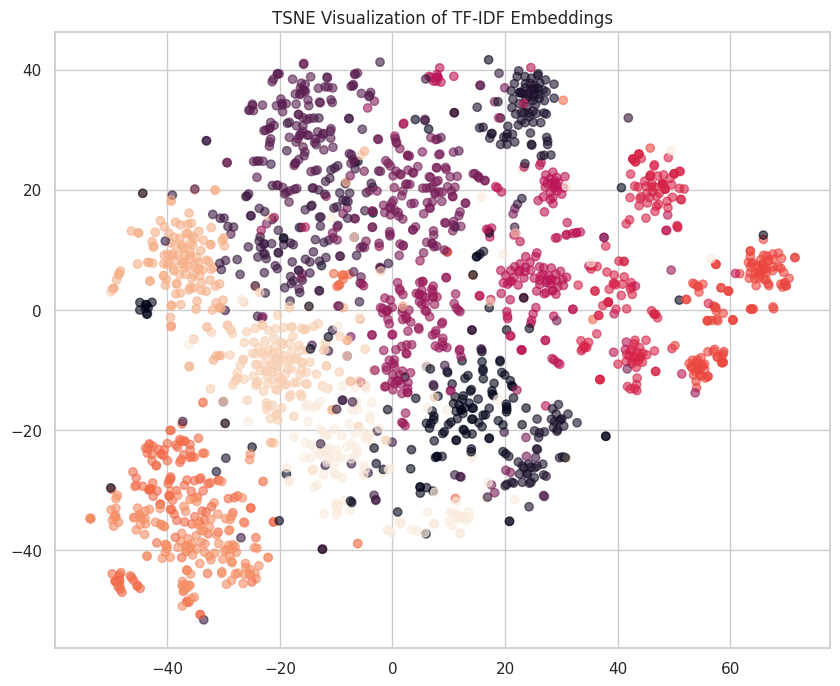

In [ ]:
from sklearn.manifold import TSNE
import numpy as np

sample = train_df.sample(2000, random_state=42)
tfidf_small = TfidfVectorizer(max_features=2000).fit_transform(sample["text"])

tsne = TSNE(n_components=2, random_state=42)
embeddings = tsne.fit_transform(tfidf_small.toarray())

plt.figure(figsize=(10,8))
plt.scatter(embeddings[:,0], embeddings[:,1], c=sample["label"], alpha=0.6)
plt.title("TSNE Visualization of TF-IDF Embeddings")
plt.show()


#**Baseline Model: TF-IDF + Linear SVM**

Trains a classical baseline model and evaluates it on validation and test sets.

In [16]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix

pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=50000, ngram_range=(1,2))),
    ("clf", LinearSVC())
])

pipeline.fit(train_texts.tolist(), train_labels.tolist())


Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_features=50000, ngram_range=(1, 2))),
                ('clf', LinearSVC())])

In [17]:
# Evaluation
svm_val_preds = pipeline.predict(val_texts.tolist())
svm_test_preds = pipeline.predict(test_df["text"].tolist())

In [18]:
print("Validation Report (TF-IDF + SVM):")
print(classification_report(val_labels, svm_val_preds))

Validation Report (TF-IDF + SVM):
              precision    recall  f1-score   support

           0       0.97      0.97      0.97      4000
           1       0.99      0.99      0.99      4000
           2       0.98      0.97      0.98      4000
           3       1.00      1.00      1.00      4000
           4       0.99      0.98      0.98      4000
           5       0.99      0.99      0.99      4000
           6       0.98      0.98      0.98      4000
           7       0.99      1.00      0.99      4000
           8       1.00      1.00      1.00      4000
           9       0.99      0.99      0.99      4000
          10       0.99      0.99      0.99      4000
          11       0.99      0.99      0.99      4000
          12       0.99      0.99      0.99      4000
          13       0.98      0.98      0.98      4000

    accuracy                           0.99     56000
   macro avg       0.99      0.99      0.99     56000
weighted avg       0.99      0.99      0.99   

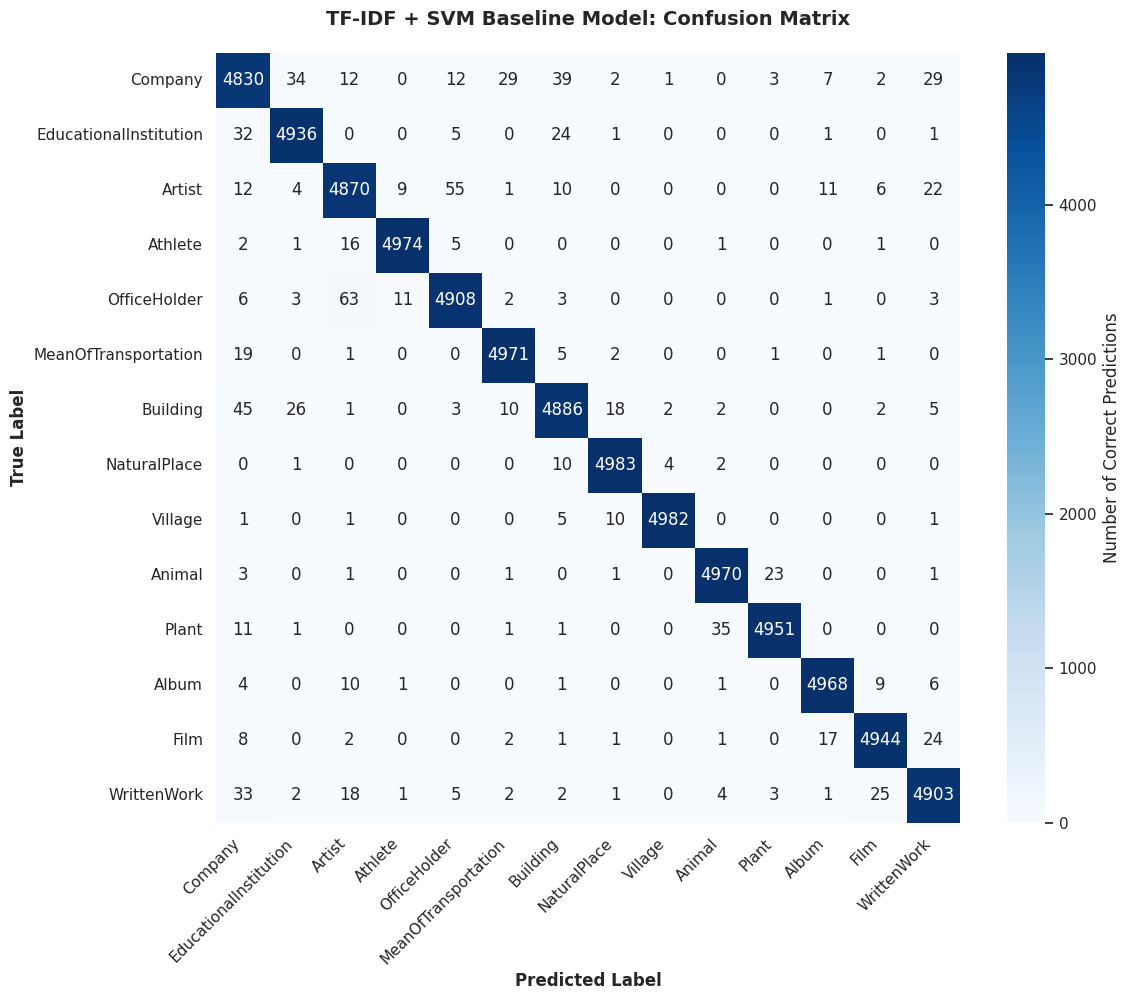

In [20]:
class_names = []
with open(os.path.join(DRIVE_ROOT, "classes.txt"), "r") as f:
    class_names = [line.strip() for line in f if line.strip()]

cm = confusion_matrix(test_df["label"], svm_test_preds)
plt.figure(figsize=(12,10))
ax = sns.heatmap(cm, cmap="Blues", annot=True, fmt='d', cbar_kws={'label': 'Number of Correct Predictions'},
                 xticklabels=[f"{class_names[i]}" if i < len(class_names) else str(i) for i in range(14)],
                 yticklabels=[f"{class_names[i]}" if i < len(class_names) else str(i) for i in range(14)])
plt.title("TF-IDF + SVM Baseline Model: Confusion Matrix",
          fontsize=14, fontweight='bold', pad=20)
plt.xlabel("Predicted Label", fontsize=12, fontweight='bold')
plt.ylabel("True Label", fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.show()

The confusion matrix shows that the TF-IDF + Linear SVM baseline performs extremely well on the DBpedia ontology classification task. Each class has 5,000 test samples, and most diagonal values are between 4,850–4,980, meaning the SVM correctly classifies 97%–99% of samples across nearly all categories.

Here we can also see for each label where it has mislabelled some of the entries. In most of the cases the misclassification is done between some semantically similar labels like for example between Company, Educational Instituion and Building. These labels have some words repeatedd amongst the "text" of their entries.

But overall misclassification counts are extremely small relative to class size.

#**Save the trained TF-IDF + SVM baseline**

This is done so that we dont have to train the SVM model every time in future runs

In [21]:
import joblib

BASELINE_SAVE_PATH = os.path.join(DRIVE_ROOT, "tfidf_svm_baseline.pkl")
joblib.dump(pipeline, BASELINE_SAVE_PATH)

print("Saved baseline model to:", BASELINE_SAVE_PATH)


Saved baseline model to: /content/drive/MyDrive/dbpedia_project/tfidf_svm_baseline.pkl


##**Load the saved TF-IDF + SVM baseline later**

For later runs only load the model to conduct tests on it

In [22]:
import joblib

BASELINE_SAVE_PATH = os.path.join(DRIVE_ROOT, "tfidf_svm_baseline.pkl")
svm_baseline = joblib.load(BASELINE_SAVE_PATH)

print("Loaded baseline model.")


Loaded baseline model.


##**Use it for predictions( when want to use/load later)**

In [23]:
preds = svm_baseline.predict(test_df["text"].tolist())

from sklearn.metrics import classification_report
print(classification_report(test_df["label"], preds))


              precision    recall  f1-score   support

           0       0.96      0.97      0.97      5000
           1       0.99      0.99      0.99      5000
           2       0.97      0.97      0.97      5000
           3       1.00      0.99      1.00      5000
           4       0.98      0.98      0.98      5000
           5       0.99      0.99      0.99      5000
           6       0.98      0.98      0.98      5000
           7       0.99      1.00      0.99      5000
           8       1.00      1.00      1.00      5000
           9       0.99      0.99      0.99      5000
          10       0.99      0.99      0.99      5000
          11       0.99      0.99      0.99      5000
          12       0.99      0.99      0.99      5000
          13       0.98      0.98      0.98      5000

    accuracy                           0.99     70000
   macro avg       0.99      0.99      0.99     70000
weighted avg       0.99      0.99      0.99     70000



#**BERT model** (do not run this whole section afterwards, the model is already trained and stored)

The following was done just to check the model progress while it was getting trained

In [ ]:
# Create HF datasets
train_ds = Dataset.from_dict({"text": train_texts.tolist(), "label": train_labels.tolist()})
val_ds   = Dataset.from_dict({"text": val_texts.tolist(),   "label": val_labels.tolist()})
test_ds  = Dataset.from_dict({"text": test_df["text"].tolist(),  "label": test_df["label"].tolist()})

In [ ]:
# Choose a model checkpoint (distilbert is faster; change to 'bert-base-uncased' if preferred)
MODEL_CKPT = "distilbert-base-uncased"
MAX_LENGTH = 256

tokenizer = AutoTokenizer.from_pretrained(MODEL_CKPT)

In [ ]:
def tokenize_function(batch):
    return tokenizer(batch["text"], truncation=True, padding="max_length", max_length=MAX_LENGTH)

# Tokenize & set format for PyTorch
train_ds = train_ds.map(tokenize_function, batched=True)
val_ds   = val_ds.map(tokenize_function, batched=True)
test_ds  = test_ds.map(tokenize_function, batched=True)

In [ ]:
train_ds.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])
val_ds.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])
test_ds.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])

print("Tokenization complete. Example keys:", train_ds.column_names)

##**Define metrics and training utilities**

In [ ]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report, confusion_matrix
from transformers import AutoModelForSequenceClassification, TrainingArguments, Trainer, DataCollatorWithPadding

In [ ]:
def compute_metrics(pred):
    labels = pred.label_ids
    preds = np.argmax(pred.predictions, axis=1)
    acc = accuracy_score(labels, preds)
    prec, rec, f1, _ = precision_recall_fscore_support(labels, preds, average="weighted")
    return {"accuracy": acc, "precision": prec, "recall": rec, "f1": f1}

##**Prepare model & Trainer + Training the BERT model**

In [ ]:
import torch
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

num_labels = 14

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_CKPT,
    num_labels=num_labels
)

# Enable gradient checkpointing for large models on T4
model.gradient_checkpointing_enable()

# Move model to GPU EARLY before Trainer wraps it
model.to(device)
print("Model device:", next(model.parameters()).device)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir=CHECKPOINTS_DIR,
    eval_strategy="epoch",
    save_strategy="epoch",
    num_train_epochs=3,
    per_device_train_batch_size=8,     # smaller = faster on T4
    per_device_eval_batch_size=16,
    learning_rate=2e-5,
    weight_decay=0.01,
    logging_steps=50,
    save_total_limit=1,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    fp16=True,                         # force GPU mixed precision
    optim="adamw_torch_fused",         # fastest optimizer on GPU
    max_grad_norm=1.0,
    dataloader_num_workers=2,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

print("Trainer device:", trainer.args.device)


In [ ]:
trainer.train()

The trained model is stored

In [ ]:
trainer.save_model(MODEL_SAVE_DIR)
tokenizer.save_pretrained(MODEL_SAVE_DIR)
print("Saved model to:", MODEL_SAVE_DIR)

##**Load Fine-Tuned DistilBERT from Drive(Only after the trained model is saved on the drive)**

In [24]:
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification

device = "cuda" if torch.cuda.is_available() else "cpu"

tokenizer = AutoTokenizer.from_pretrained(MODEL_SAVE_DIR)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_SAVE_DIR)
model.to(device)
model.eval()

print("Loaded model on:", device)

Loaded model on: cuda


##**Prepare Dataset for BERT Evaluation**

In [25]:
from datasets import Dataset

test_ds = Dataset.from_dict({
    "text": test_df["text"].tolist(),
    "label": test_df["label"].tolist()
})

def tokenize(batch):
    return tokenizer(batch["text"], truncation=True, padding=True, max_length=128)

test_ds = test_ds.map(tokenize, batched=True)
test_ds.set_format(type="torch", columns=["input_ids","attention_mask","label"])


Map:   0%|          | 0/70000 [00:00<?, ? examples/s]

#**Evaluate the Loaded BERT Model**

In [26]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# Manual prediction
all_preds = []
all_labels = []

for batch in test_ds:
    input_ids = batch["input_ids"].unsqueeze(0).to(device)
    attn = batch["attention_mask"].unsqueeze(0).to(device)
    label = batch["label"]

    with torch.no_grad():
        logits = model(input_ids, attention_mask=attn).logits
        pred = logits.argmax(-1).item()

    all_preds.append(pred)
    all_labels.append(label)

In [27]:
print("Test Report (Loaded DistilBERT):")
print(classification_report(all_labels, all_preds, digits=4))

Test Report (Loaded DistilBERT):
              precision    recall  f1-score   support

           0     0.9781    0.9726    0.9753      5000
           1     0.9878    0.9910    0.9894      5000
           2     0.9843    0.9912    0.9877      5000
           3     0.9964    0.9982    0.9973      5000
           4     0.9914    0.9866    0.9890      5000
           5     0.9946    0.9970    0.9958      5000
           6     0.9872    0.9842    0.9857      5000
           7     0.9978    0.9970    0.9974      5000
           8     0.9980    0.9994    0.9987      5000
           9     0.9984    0.9990    0.9987      5000
          10     0.9990    0.9964    0.9977      5000
          11     0.9974    0.9962    0.9968      5000
          12     0.9974    0.9946    0.9960      5000
          13     0.9904    0.9948    0.9926      5000

    accuracy                         0.9927     70000
   macro avg     0.9927    0.9927    0.9927     70000
weighted avg     0.9927    0.9927    0.9927    

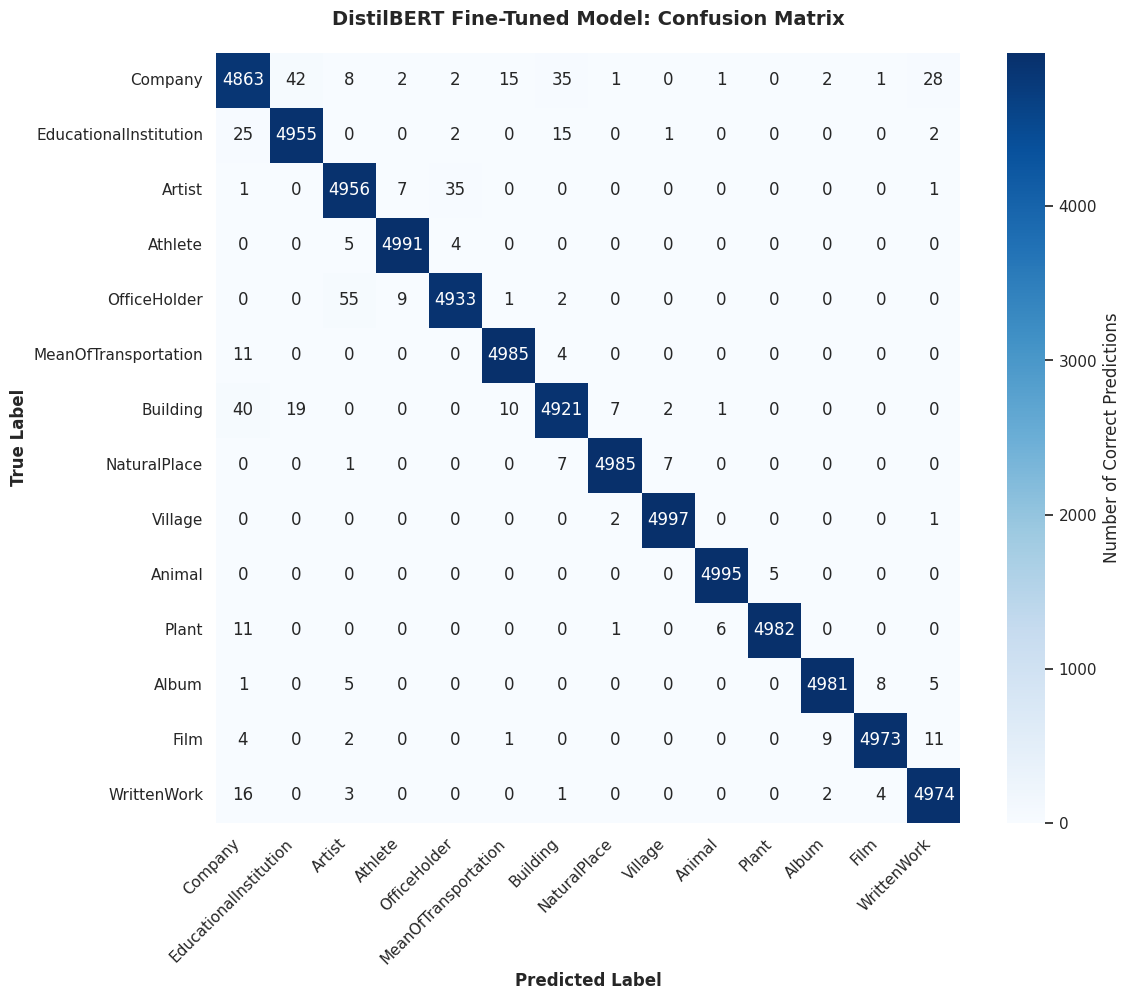

In [28]:
class_names = []
with open(os.path.join(DRIVE_ROOT, "classes.txt"), "r") as f:
    class_names = [line.strip() for line in f if line.strip()]

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(12,10))
ax = sns.heatmap(cm, cmap="Blues", annot=True, fmt='d', cbar_kws={'label': 'Number of Correct Predictions'},
                 xticklabels=[f"{class_names[i]}" if i < len(class_names) else str(i) for i in range(14)],
                 yticklabels=[f"{class_names[i]}" if i < len(class_names) else str(i) for i in range(14)])
plt.title("DistilBERT Fine-Tuned Model: Confusion Matrix",
          fontsize=14, fontweight='bold', pad=20)
plt.xlabel("Predicted Label", fontsize=12, fontweight='bold')
plt.ylabel("True Label", fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.show()


The DistilBERT fine-tuned model shows exceptionally strong classification performance across all 14 DBpedia categories. Similar to the SVM model, BERT model also has some misclassifications based on the similar semantic lables. But it is a improvement over the SVM model if we count the total number of misclassifications, BERT model has fewer misclassifications.

BERT model shows excellent feature understanding and the ability to model long-range semantic structure.

#**Compare SVM vs DistilBERT**

In [46]:
from sklearn.metrics import precision_recall_fscore_support

svm_prf = precision_recall_fscore_support(test_df["label"], svm_test_preds, average=None, zero_division=0)
bert_prf = precision_recall_fscore_support(test_df["label"], all_preds, average=None, zero_division=0)

per_class_results = pd.DataFrame({
    "Class": class_names,
    "SVM_F1": svm_prf[2],
    "BERT_F1": bert_prf[2]
})

per_class_results

,Class,SVM_F1,BERT_F1
0,Company,0.965421,0.975331
1,EducationalInstitution,0.986411,0.989417
2,Artist,0.974487,0.987743
3,Athlete,0.995198,0.997302
4,OfficeHolder,0.982288,0.988974
5,MeanOfTransportation,0.992315,0.995805
6,Building,0.978472,0.985679
7,NaturalPlace,0.994710,0.997399
8,Village,0.997497,0.998701
9,Animal,0.992412,0.998700


In [29]:
from sklearn.metrics import accuracy_score, f1_score

svm_acc = accuracy_score(test_df["label"], svm_test_preds)
svm_f1  = f1_score(test_df["label"], svm_test_preds, average="weighted")

bert_acc = accuracy_score(all_labels, all_preds)
bert_f1  = f1_score(all_labels, all_preds, average="weighted")

summary = pd.DataFrame({
    "Model": ["TF-IDF + SVM", "DistilBERT"],
    "Accuracy": [svm_acc, bert_acc],
    "F1-weighted": [svm_f1, bert_f1]
})


In [30]:
summary

,Model,Accuracy,F1-weighted
0,TF-IDF + SVM,0.986800,0.986799
1,DistilBERT,0.992729,0.992725


The TF-IDF + SVM baseline already performs extremely well on the DBpedia dataset, achieving 98.68% accuracy and a 0.9868 weighted F1-score, reflecting the strong separability of the classes with traditional bag-of-words representations. However, the fine-tuned DistilBERT model consistently outperforms the SVM across every single class. Per-class F1 improvements range from +0.3% to +1.8%, with the largest gains observed in text-rich categories such as Artist, WrittenWork, and Company. DistilBERT achieves an overall 99.27% accuracy and 0.9927 weighted F1-score, showing its superior ability to capture contextual and semantic cues—especially in cases where SVM relies heavily on surface-level n-grams.

Example some of the Misclassified points

In [47]:
mis_idx = np.where(np.array(all_labels) != np.array(all_preds))[0]
print("Showing 5 Misclassified Samples:\n")

for i in mis_idx[:5]:
    print("Text:", test_df.iloc[i]["text"][:300], "...")
    print("True:", class_names[all_labels[i]])
    print("Pred:", class_names[all_preds[i]])
    print("---")

Showing 5 Misclassified Samples:

Text: Korchma Taras Bulba.  Korchma Taras Bulba – the chain of restaurants which was developed by Juriy Beloivan in 1999. ...
True: Company
Pred: Building
---
Text: Government of the Democratic Republic of the Congo.  The Government of the Democratic Republic of the Congo is the second institution in the central executive branch of the Democratic Republic of the Congo the first institution being the President of the Democratic Republic of the Congo who has the  ...
True: Company
Pred: OfficeHolder
---
Text: National Association for Interpretation.  The National Association for Interpretation is a non-profit professional association of natural and cultural resources interpreters primarily in the United States. It is based in Fort Collins Colorado. NAI provides training and certification programs. The NA ...
True: Company
Pred: WrittenWork
---
Text: Student Volunteer Campus Community.  Student Volunteer Campus Community (abbreviated SVCC and formerly SVC

#**LIME Explainability**

LIME (Local Interpretable Model-Agnostic Explanations) is a technique used to explain why a machine learning model made a specific prediction.

It explains why a model made a particular prediction by showing which words were most responsible for pushing the model toward or away from each class.

##LIME for BERT model

In [31]:
from lime.lime_text import LimeTextExplainer


class_names = []
with open(os.path.join(DRIVE_ROOT, "classes.txt"), "r") as f:
    class_names = [line.strip() for line in f if line.strip()]

explainer = LimeTextExplainer(class_names=class_names)


def predict_proba_for_lime(texts):
    model.eval()
    # Process texts in smaller batches to avoid OOM
    batch_size = 16 # Adjust based on GPU memory. 32-64 is usually a good starting point.
    all_probs = []
    for i in range(0, len(texts), batch_size):
        batch_texts = texts[i:i+batch_size]
        enc = tokenizer(batch_texts, return_tensors="pt", padding=True, truncation=True, max_length=128)
        enc = {k: v.to(device) for k, v in enc.items()}
        with torch.no_grad():
            logits = model(**enc).logits
            probs = torch.softmax(logits, dim=1).cpu().numpy()
        all_probs.append(probs)
    return np.vstack(all_probs)


Pick a test sample

Text: Campus Management Corp..  Campus Management Corp. is a private company that provides software and services to colleges universities foundations and other companies.
True Label: Company
Top Prediction: Company (prob: 0.9997)
2nd Best: Plant (prob: 0.0001)


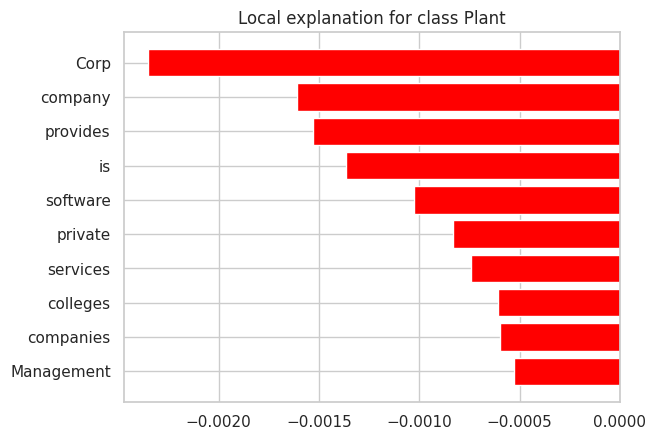

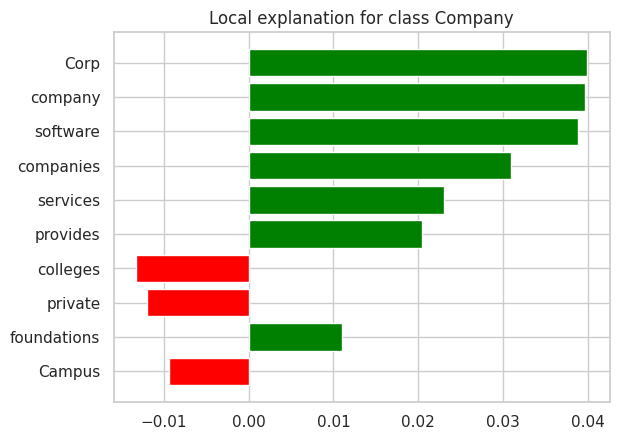

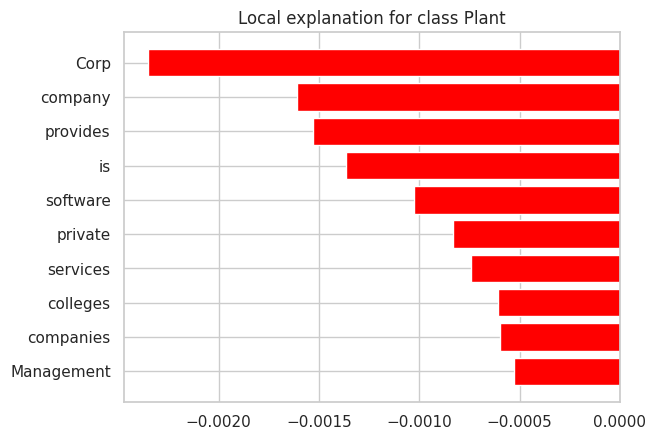

In [32]:
sample_idx = 60
sample_text = test_df.iloc[sample_idx]["text"]
true_label  = test_df.iloc[sample_idx]["label"]

print("Text:", sample_text[:400])
print("True Label:", class_names[true_label])

probs = predict_proba_for_lime([sample_text])[0]
predicted_class = int(np.argmax(probs))
second_best_class = int(np.argsort(probs)[-2])  # Get 2nd highest probability

print("Top Prediction:", class_names[predicted_class], f"(prob: {probs[predicted_class]:.4f})")
print("2nd Best:", class_names[second_best_class], f"(prob: {probs[second_best_class]:.4f})")

exp = explainer.explain_instance(sample_text, predict_proba_for_lime, top_labels=2)

exp.as_pyplot_figure(label=predicted_class)
exp.as_pyplot_figure(label=second_best_class)


Save LIME Outputs

In [33]:

html = exp.as_html(labels=[predicted_class, second_best_class])
with open(os.path.join(MODEL_SAVE_DIR, "lime_sample.html"), "w") as f:
    f.write(html)

print("Saved at:", os.path.join(MODEL_SAVE_DIR, "lime_sample.html"))


Saved at: /content/drive/MyDrive/dbpedia_project/model/lime_sample.html


##LIME for SVM model

Text: Campus Management Corp..  Campus Management Corp. is a private company that provides software and services to colleges universities foundations and other companies.
True Label: Company
Top Prediction: Company (prob: 0.5601)
2nd Best: EducationalInstitution (prob: 0.1141)


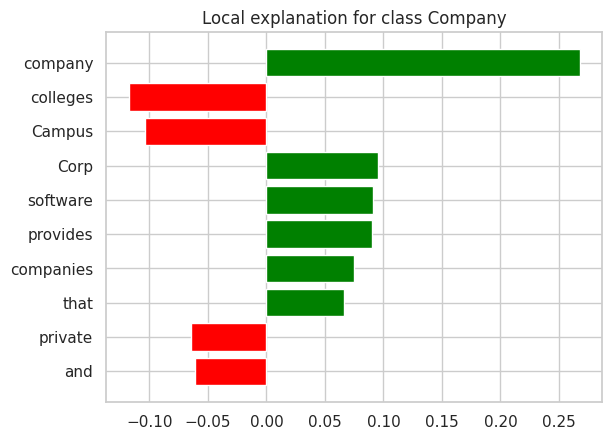


Saved at: /content/drive/MyDrive/dbpedia_project/model/lime_sample_svm.html


In [34]:
from scipy.special import softmax

def predict_proba_for_svm_lime(texts):
    decision_scores = svm_baseline.decision_function(texts)
    probs = softmax(decision_scores, axis=1)
    return probs

sample_idx = 60
sample_text = test_df.iloc[sample_idx]["text"]
true_label = test_df.iloc[sample_idx]["label"]

print("Text:", sample_text[:400])
print("True Label:", class_names[true_label])

probs_svm = predict_proba_for_svm_lime([sample_text])[0]
predicted_class_svm = int(np.argmax(probs_svm))
second_best_class_svm = int(np.argsort(probs_svm)[-2])

print("Top Prediction:", class_names[predicted_class_svm], f"(prob: {probs_svm[predicted_class_svm]:.4f})")
print("2nd Best:", class_names[second_best_class_svm], f"(prob: {probs_svm[second_best_class_svm]:.4f})")

explainer_svm = LimeTextExplainer(class_names=class_names)

exp_svm = explainer_svm.explain_instance(sample_text, predict_proba_for_svm_lime, top_labels=2)

exp_svm.as_pyplot_figure(label=predicted_class_svm)
plt.show()

html_svm = exp_svm.as_html(labels=[predicted_class_svm, second_best_class_svm])
with open(os.path.join(MODEL_SAVE_DIR, "lime_sample_svm.html"), "w") as f:
    f.write(html_svm)

print("\nSaved at:", os.path.join(MODEL_SAVE_DIR, "lime_sample_svm.html"))

In [43]:
model.save_pretrained(MODEL_SAVE_DIR, safe_serialization=False)
tokenizer.save_pretrained(MODEL_SAVE_DIR)


('/content/drive/MyDrive/dbpedia_project/model/tokenizer_config.json',
 '/content/drive/MyDrive/dbpedia_project/model/special_tokens_map.json',
 '/content/drive/MyDrive/dbpedia_project/model/vocab.txt',
 '/content/drive/MyDrive/dbpedia_project/model/added_tokens.json',
 '/content/drive/MyDrive/dbpedia_project/model/tokenizer.json')